In [2]:
import sys, os
os.path.dirname(sys.executable)

'/clusterfs/nilah/sergio/miniconda3/envs/ESM_cambrian/bin'

In [3]:
sys.path.append('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA')
from ESMCBA.imports import *
from ESMCBA import graph_utils

In [42]:
directory = '/global/scratch/users/sergiomar10/logs/ESMC_Pretrain_logs_09042025'
csv_files = glob.glob(os.path.join(directory, '*.csv'))
data = []

for file in csv_files:
    if os.path.getsize(file) > 0:
        try:
            df = pd.read_csv(file)
            df = df.replace([np.inf, -np.inf], np.nan).dropna()

            base = os.path.basename(file)
            # Remove the file extension and split by underscore
            name_parts = os.path.splitext(base)[0].split('_')
            # Expected filename parts:
            # [0]: "training"
            # [1]: "log"
            # [2]: "ESMMASK"
            # [3]: encoding           (e.g., "HLA" or "epitope")
            # [4]: "FT"
            # [5]: blocks_unfrozen    (e.g., "25")
            # [6]: base_block_lr      (e.g., "0.0001")
            # [7]: regression_block_lr (e.g., "0.001")
            # [8]: "AUG"
            # [9]: num_augmentations  (e.g., "6")
            # [10]: HLA allele        (e.g., "HLAA3001")
            # [11]: (optional, e.g., replicate index)
            if len(name_parts) >= 11:
                encoding = name_parts[3]
                blocks_unfrozen = int(name_parts[5])
                base_block_lr = float(name_parts[6])
                regression_block_lr = float(name_parts[7])
                num_augmentations = int(name_parts[9])
                hla_allele = name_parts[10]
            else:
                encoding = 'Unknown'
                blocks_unfrozen = None
                base_block_lr = None
                regression_block_lr = None
                num_augmentations = None
                hla_allele = 'Unknown'
                
            max_val_acc = df['Val Acc'].max() if 'Val Acc' in df.columns else None
            
            data.append({
                'file': file,
                'filename': base,
                'encoding': encoding,
                'blocks_unfrozen': blocks_unfrozen,
                'base_block_lr': base_block_lr,
                'regression_block_lr': regression_block_lr,
                'num_augmentations': num_augmentations,
                'HLA_allele': hla_allele,
                'max_val_acc': max_val_acc
            })
        except Exception as e:
            print(f"Error reading {file}: {e}")
            continue

df_summary = pd.DataFrame(data)


In [43]:
df_summary['HLA_allele'].value_counts().head(10)

HLA_allele
A0201    112
B3909     17
A3207     17
B3906     16
C0401     16
B1517     16
A0204     15
B4601     15
A3215     15
B2710     14
Name: count, dtype: int64

In [44]:
df_summary['BU_HLA'] = df_summary['base_block_lr'].astype(str) + ' + ' + df_summary['encoding'].astype(str)

In [52]:
allele_encoding_map = df_summary.groupby('HLA_allele')['encoding'].unique()

# Find alleles that have both models
complete = allele_encoding_map[allele_encoding_map.apply(lambda x: set(x) == {'HLA', 'epitope'})]

# Find alleles missing either model
incomplete = allele_encoding_map[allele_encoding_map.apply(lambda x: set(x) != {'HLA', 'epitope'})]

print("✅ HLA alleles with both HLA and epitope models:")
print(complete)

print("\n⚠️ HLA alleles missing one of the models:")
print(incomplete)

✅ HLA alleles with both HLA and epitope models:
HLA_allele
A0101    [HLA, epitope]
A0201    [epitope, HLA]
A0202    [epitope, HLA]
A0204    [HLA, epitope]
A0205    [epitope, HLA]
              ...      
C0801    [HLA, epitope]
C0802    [HLA, epitope]
C1203    [HLA, epitope]
C1402    [HLA, epitope]
C1502    [HLA, epitope]
Name: encoding, Length: 96, dtype: object

⚠️ HLA alleles missing one of the models:
HLA_allele
B3501       [epitope]
B4002       [epitope]
B5701       [epitope]
HLAA1101    [epitope]
Name: encoding, dtype: object


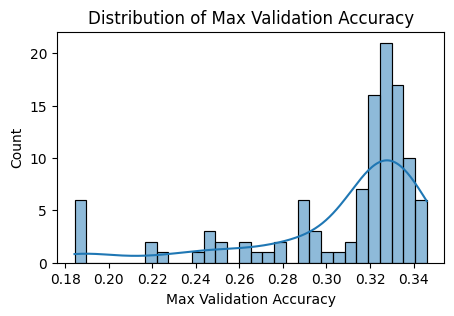

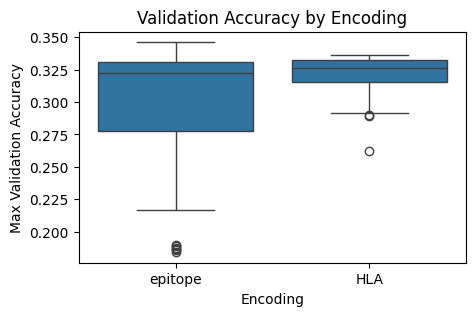

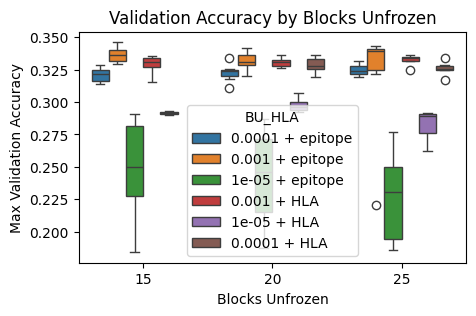

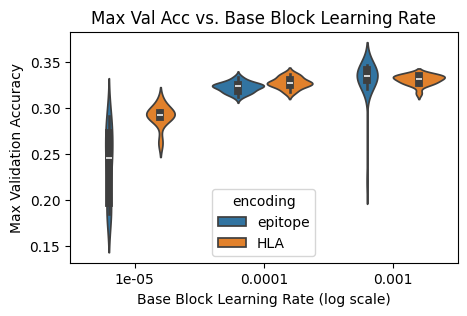

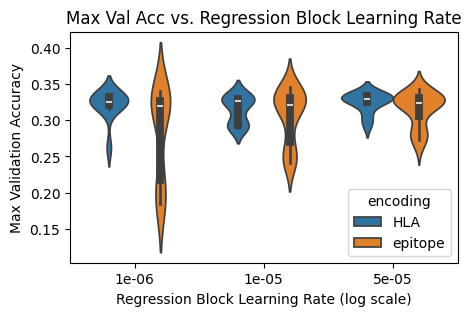

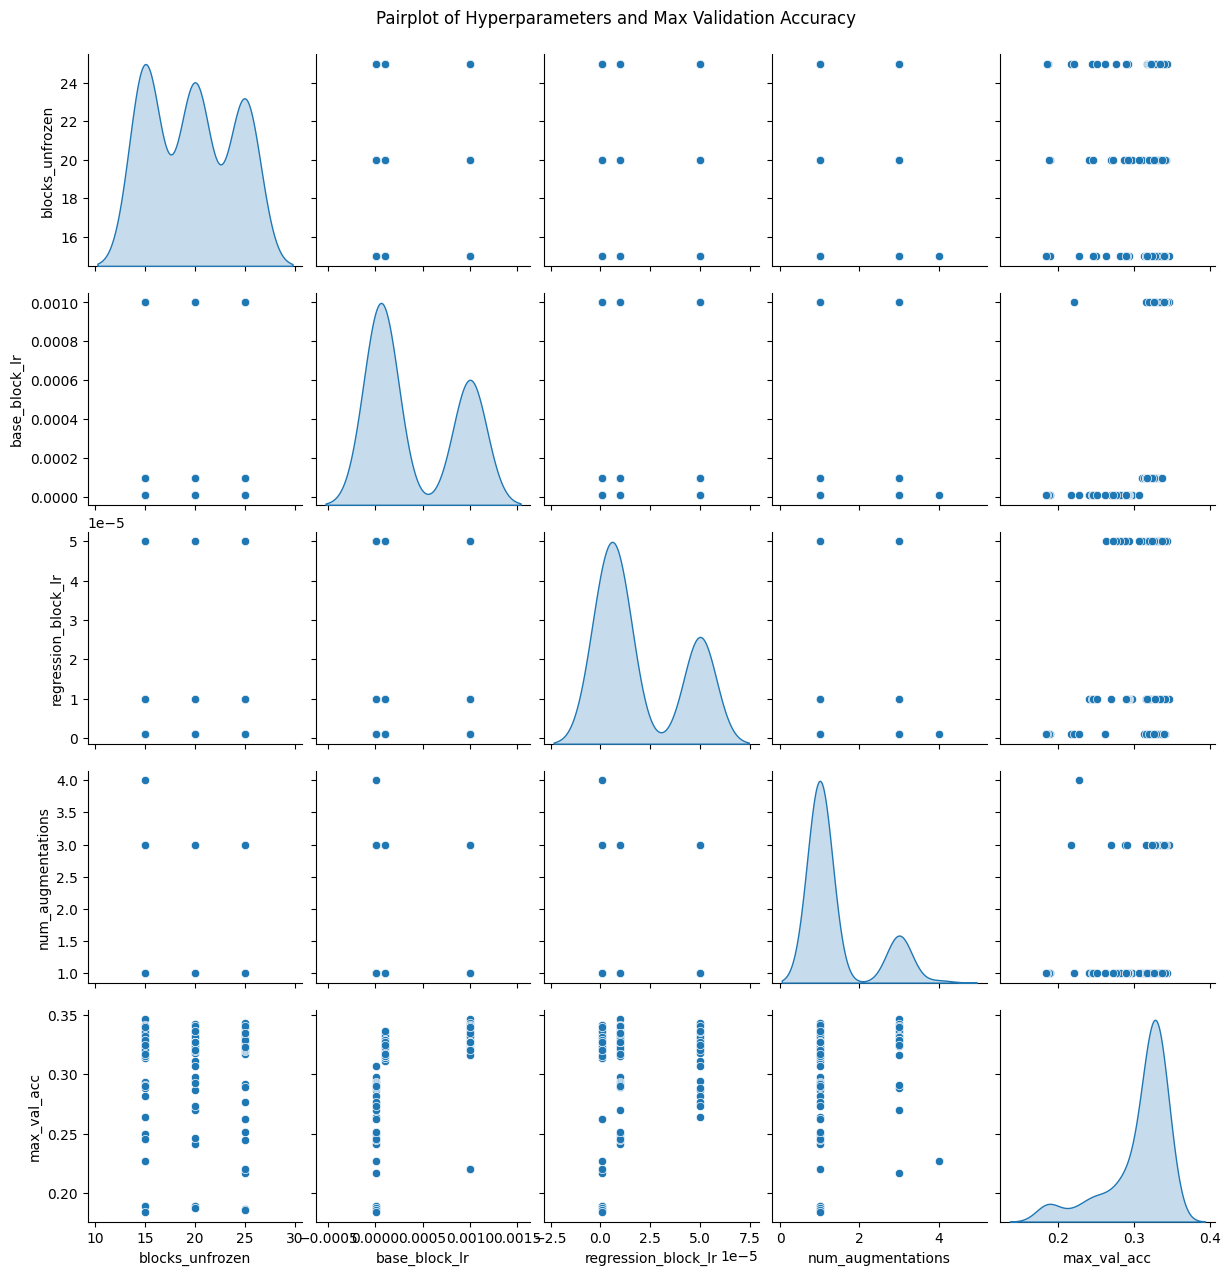

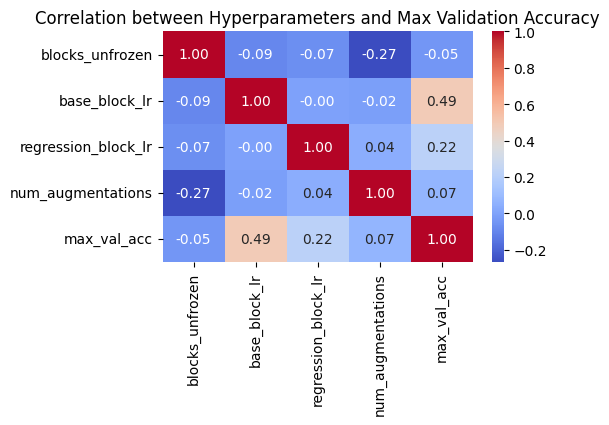

In [46]:
df_summary_subset = df_summary[df_summary['HLA_allele'] == 'A0201' ]

# 1. Histogram of max_val_acc
plt.figure(figsize=(5, 3))
sns.histplot(df_summary_subset['max_val_acc'], bins=30, kde=True)
plt.title("Distribution of Max Validation Accuracy")
plt.xlabel("Max Validation Accuracy")
plt.ylabel("Count")
plt.show()

# 2. Boxplot: Max Val Acc by Encoding
plt.figure(figsize=(5, 3))
sns.boxplot(x='encoding', y='max_val_acc', data=df_summary_subset)
plt.title("Validation Accuracy by Encoding")
plt.xlabel("Encoding")
plt.ylabel("Max Validation Accuracy")
plt.show()

# 3. Boxplot: Max Val Acc by Number of Unfrozen Blocks (if only a few distinct values)
plt.figure(figsize=(5, 3))
sns.boxplot(x='blocks_unfrozen', y='max_val_acc', hue='BU_HLA', data=df_summary_subset)
plt.title("Validation Accuracy by Blocks Unfrozen")
plt.xlabel("Blocks Unfrozen")
plt.ylabel("Max Validation Accuracy")
plt.show()

# 4. Scatter Plot: Base Block LR vs. Max Val Acc (using log scale for lr)
plt.figure(figsize=(5, 3))
sns.violinplot(x='base_block_lr', y='max_val_acc', hue='encoding', data=df_summary_subset)
# plt.xscale('log')
plt.title("Max Val Acc vs. Base Block Learning Rate")
plt.xlabel("Base Block Learning Rate (log scale)")
plt.ylabel("Max Validation Accuracy")
plt.show()

# 5. Scatter Plot: Regression Block LR vs. Max Val Acc (using log scale)
plt.figure(figsize=(5, 3))
sns.violinplot(x='regression_block_lr', y='max_val_acc', hue='encoding', data=df_summary_subset)
# plt.xscale('log')
plt.title("Max Val Acc vs. Regression Block Learning Rate")
plt.xlabel("Regression Block Learning Rate (log scale)")
plt.ylabel("Max Validation Accuracy")
plt.show()

# 6. Pairplot: Visualize all hyperparameters vs max_val_acc
selected_cols = ['blocks_unfrozen', 'base_block_lr', 'regression_block_lr', 'num_augmentations', 'max_val_acc']
sns.pairplot(df_summary_subset[selected_cols], diag_kind='kde')
plt.suptitle("Pairplot of Hyperparameters and Max Validation Accuracy", y=1.02)
plt.show()

# 7. Correlation Heatmap: Numerical hyperparameters and performance
corr_cols = ['blocks_unfrozen', 'base_block_lr', 'regression_block_lr', 'num_augmentations', 'max_val_acc']
corr_matrix = df_summary_subset[corr_cols].corr()
plt.figure(figsize=(5, 3))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation between Hyperparameters and Max Validation Accuracy")
plt.show()


In [47]:
HLAs_done = Counter([x.split('AUG')[1].split('_')[2] for x in  glob.glob('/global/scratch/users/sergiomar10/data/ESMC_Pretrain_09042025_evals/*.csv')]).keys()

In [9]:
import itertools

summary = []

for HLA in HLAs_done:

    # 1. Load all CSV files into a dictionary of DataFrames.
    trained_files = glob.glob(f'/global/scratch/users/sergiomar10/data/ESMC_Pretrain_03042025_perplexity/*{HLA}*.csv')
    trained_files = sorted(trained_files)

    print(f"Found {len(trained_files)} files.")

    models = {}
    model_names = []
    for file in trained_files:

        if os.path.getsize(file) < 10:
            print(f"Skipping empty file: {file}")
            continue

        df = pd.read_csv(file)
        
        base = os.path.basename(file)
        # Remove common prefix and suffix to get a shorter model name.
        # For example: "training_log_ESMMASK_" and ".csv"
        name = base.replace("ESMMASK_epitope_", "").replace(".csv", "").split('_HLA')[0]
        models[name] = df
        model_names.append(name)

        # Summarize average token_nll for each model
        avg_nll = df['token_nll'].mean()

        summary.append({
        'File': os.path.basename(file),
        'HLA': HLA,
        'Avg_Token_NLL': avg_nll
    })
    # for name, df in models.items():
    #     avg_nll[name] = df['token_nll'].mean()

    # # Sort by lowest average negative log-likelihood
    # best_models_by_nll = sorted(avg_nll.items(), key=lambda x: x[1])
    # print("Best models by average token NLL:")
    # for name, score in best_models_by_nll:
    #     print(f"{name}: {score:.4f}")

summary_df = pd.DataFrame(summary)
summary_df = summary_df.sort_values(by='Avg_Token_NLL')
summary_df = summary_df[summary_df['Avg_Token_NLL'] > 0 ]

Found 10 files.
Found 12 files.
Found 7 files.
Found 10 files.
Found 0 files.
Found 13 files.
Found 10 files.
Found 10 files.
Found 10 files.
Found 0 files.
Found 12 files.
Found 7 files.
Found 9 files.
Found 10 files.
Found 8 files.
Skipping empty file: /global/scratch/users/sergiomar10/data/ESMC_Pretrain_03042025_perplexity/ESMMASK_epitope_FT_20_0.001_5e-05_AUG_1_HLAB4201_2_per_token_metrics.csv
Found 8 files.
Found 7 files.
Found 12 files.
Found 14 files.
Found 9 files.
Found 10 files.
Found 7 files.
Found 7 files.
Found 13 files.
Found 12 files.
Found 8 files.
Found 7 files.
Found 8 files.
Found 14 files.
Found 10 files.
Found 11 files.
Found 9 files.
Found 12 files.
Found 7 files.
Skipping empty file: /global/scratch/users/sergiomar10/data/ESMC_Pretrain_03042025_perplexity/ESMMASK_epitope_FT_20_0.001_5e-05_AUG_1_HLAB3503_2_per_token_metrics.csv
Skipping empty file: /global/scratch/users/sergiomar10/data/ESMC_Pretrain_03042025_perplexity/ESMMASK_epitope_FT_25_0.001_1e-06_AUG_6_HLAB

In [10]:
sum_subset = summary_df[summary_df['Avg_Token_NLL'] > 0 ]

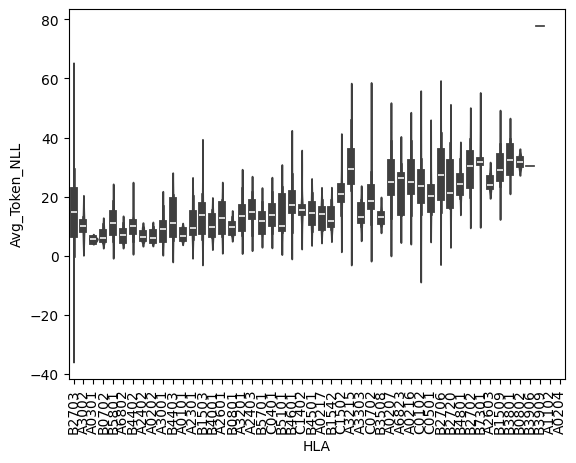

In [11]:
sns.violinplot(data = sum_subset[sum_subset['HLA'].isin(sum_subset['HLA'].value_counts().reset_index().head(50)['HLA'])],
                x = 'HLA',
                y= 'Avg_Token_NLL')

plt.xticks(rotation=90)
plt.show()

In [48]:
df_summary['HLA_allele'].value_counts().head(30)

HLA_allele
A0201    112
B3909     17
A3207     17
B3906     16
C0401     16
B1517     16
A0204     15
B4601     15
A3215     15
B2710     14
B3508     14
A6812     14
A0202     14
B8301     14
A3002     14
B5801     13
B4801     13
B7301     13
A2602     13
C0702     13
C1203     13
A2601     13
C0303     13
A2403     13
A0219     12
B0802     12
A0101     12
A8001     12
A0207     12
B5501     12
Name: count, dtype: int64

Found 111 files.
_HLA_FT_15_0.001_1e-05_AUG_1_A0201_1: Accuracy = 0.315
_HLA_FT_15_0.001_1e-05_AUG_1_A0201_2: Accuracy = 0.322
_HLA_FT_15_0.001_1e-06_AUG_1_A0201_1: Accuracy = 0.318
_HLA_FT_15_0.001_1e-06_AUG_1_A0201_2: Accuracy = 0.315
_HLA_FT_15_0.001_5e-05_AUG_1_A0201_1: Accuracy = 0.335
_HLA_FT_15_0.001_5e-05_AUG_1_A0201_2: Accuracy = 0.317
_HLA_FT_15_1e-05_1e-05_AUG_1_A0201_1: Accuracy = 0.298
_HLA_FT_15_1e-05_1e-05_AUG_1_A0201_2: Accuracy = 0.293
_HLA_FT_20_0.0001_1e-05_AUG_1_A0201_1: Accuracy = 0.301
_HLA_FT_20_0.0001_1e-05_AUG_1_A0201_2: Accuracy = 0.313
_HLA_FT_20_0.0001_1e-06_AUG_1_A0201_1: Accuracy = 0.304
_HLA_FT_20_0.0001_1e-06_AUG_1_A0201_2: Accuracy = 0.306
_HLA_FT_20_0.0001_5e-05_AUG_1_A0201_1: Accuracy = 0.327
_HLA_FT_20_0.0001_5e-05_AUG_1_A0201_2: Accuracy = 0.317
_HLA_FT_20_0.001_1e-05_AUG_1_A0201_1: Accuracy = 0.318
_HLA_FT_20_0.001_1e-05_AUG_1_A0201_2: Accuracy = 0.310
_HLA_FT_20_0.001_1e-06_AUG_1_A0201_1: Accuracy = 0.330
_HLA_FT_20_0.001_1e-06_AUG_1_A0201_2: Accu

/tmp/ipykernel_2171231/3787631750.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.88, 1])


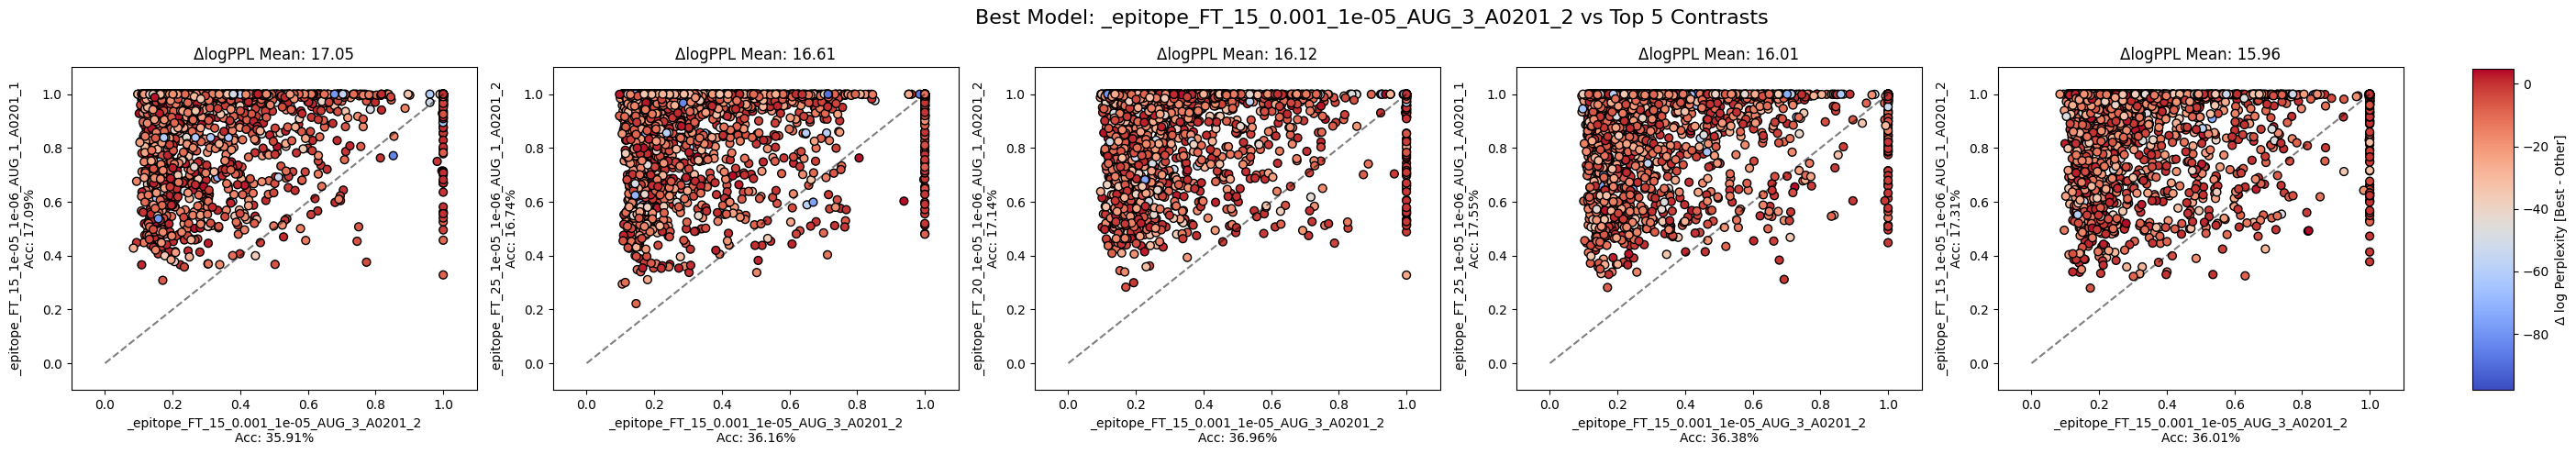

In [33]:
import glob
import os
import pandas as pd
import itertools
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Load models
trained_files = glob.glob('/global/scratch/users/sergiomar10/data/ESMC_Pretrain_09042025_perplexity/*A0201*.csv')
trained_files = sorted(trained_files)
print(f"Found {len(trained_files)} files.")

models = {}
accuracies = {}
model_names = []

for file in trained_files:
    df = pd.read_csv(file)
    base = os.path.basename(file)
    name = base.replace("ESMMASK", "").replace("_per_token_metrics.csv", "")
    models[name] = df
    model_names.append(name)

    # Compute accuracy
    if 'original_id' in df.columns and 'predicted_id' in df.columns:
        accuracy = (df['original_id'] == df['predicted_id']).mean()
        accuracies[name] = accuracy
        print(f"{name}: Accuracy = {accuracy:.3f}")

# Step 2: Select best model (based on accuracy)
best_model = max(accuracies, key=accuracies.get)
print(f"\nBest model: {best_model} with accuracy {accuracies[best_model]:.3f}")

# Step 3: Compare best model to all others and compute delta log perplexity
comparison_stats = []

for other_model in model_names:
    if other_model == best_model:
        continue

    df1 = models[best_model]
    df2 = models[other_model]

    df_merged = pd.merge(df1, df2, on=['epitope', 'original_id'], how='inner',
                         suffixes=('_model1', '_model2'))

    df_merged['delta_log_ppl'] = df_merged['token_nll_model1'] - df_merged['token_nll_model2']

    df_merged = df_merged.replace([np.inf, -np.inf], np.nan).dropna()

    acc_model1 = (df_merged['original_id'] == df_merged['predicted_id_model1']).mean()
    acc_model2 = (df_merged['original_id'] == df_merged['predicted_id_model2']).mean()

    mean_delta = np.abs(df_merged['delta_log_ppl']).mean()

    comparison_stats.append({
        'model2': other_model,
        'acc_model1': acc_model1,
        'acc_model2': acc_model2,
        'mean_delta_log_ppl': mean_delta,
        'df_merged': df_merged
    })

# Step 4: Sort comparisons by mean delta log perplexity and take top 5
top_comparisons = sorted(comparison_stats, key=lambda x: -x['mean_delta_log_ppl'])[:5]

# Step 5: Plot
fig, axes = plt.subplots(1, 5, figsize=(30, 5), squeeze=False)

for i, comp in enumerate(top_comparisons):
    ax = axes[0, i]
    df_merged = comp['df_merged']
    
    scatter_obj = ax.scatter(
        df_merged['predicted_prob_model1'],
        df_merged['predicted_prob_model2'],
        c=df_merged['delta_log_ppl'],
        cmap='coolwarm',
        s=40,
        edgecolor='k'
    )
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    ax.set_xlim(-0.1, 1.1)
    ax.set_ylim(-0.1, 1.1)

    ax.set_xlabel(f"{best_model}\nAcc: {comp['acc_model1']:.2%}")
    ax.set_ylabel(f"{comp['model2']}\nAcc: {comp['acc_model2']:.2%}")
    ax.set_title(f"ΔlogPPL Mean: {comp['mean_delta_log_ppl']:.2f}")

# Colorbar
fig.subplots_adjust(right=0.88)
cbar_ax = fig.add_axes([0.90, 0.15, 0.015, 0.7])
fig.colorbar(scatter_obj, cax=cbar_ax, label="Δ log Perplexity [Best - Other]")

fig.suptitle(f"Best Model: {best_model} vs Top 5 Contrasts", fontsize=16)
plt.tight_layout(rect=[0, 0, 0.88, 1])
plt.show()


In [ ]:
break

In [14]:
logits_path = '/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/ESMCBA/logits.csv'
df = pd.read_csv(logits_path, index_col=0)
df.index = list('YLQPRTFLL')

FileNotFoundError: [Errno 2] No such file or directory: '/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/ESMCBA/logits.csv'

In [ ]:
pd.set_option('display.max_columns', None)

Raw logits matrix shape: (9, 33)
Raw logits matrix:
       <cls>       <pad>      <eos>       <unk>          L          A  \
Y -97.677280 -149.410160  103.12598 -103.347885  48.412518  77.155106   
L -82.760025 -132.327800   88.93860  -91.231040  48.129993  67.766660   
Q -79.408424 -123.748184   83.75126  -85.277310  44.741207  63.890453   
P -57.983646  -95.233920   78.15236  -90.048450  38.789590  62.112900   
R -56.014927  -93.093980   75.14153  -85.628590  38.320923  59.511030   

           G           V          S          E          R          T  \
Y -37.374836  138.870360  76.022250 -59.548172 -43.002457 -121.66588   
L -34.155210  118.684555  61.766594 -56.124130 -39.532536 -104.81594   
Q -33.794327  110.719574  55.333080 -51.880432 -39.223750  -97.23726   
P -24.165365   90.738500  38.555622 -40.868640 -43.085840  -87.18355   
R -23.487082   88.671310  39.043570 -41.088696 -42.450886  -85.96540   

           I           D          P          K           Q          N  \
Y -

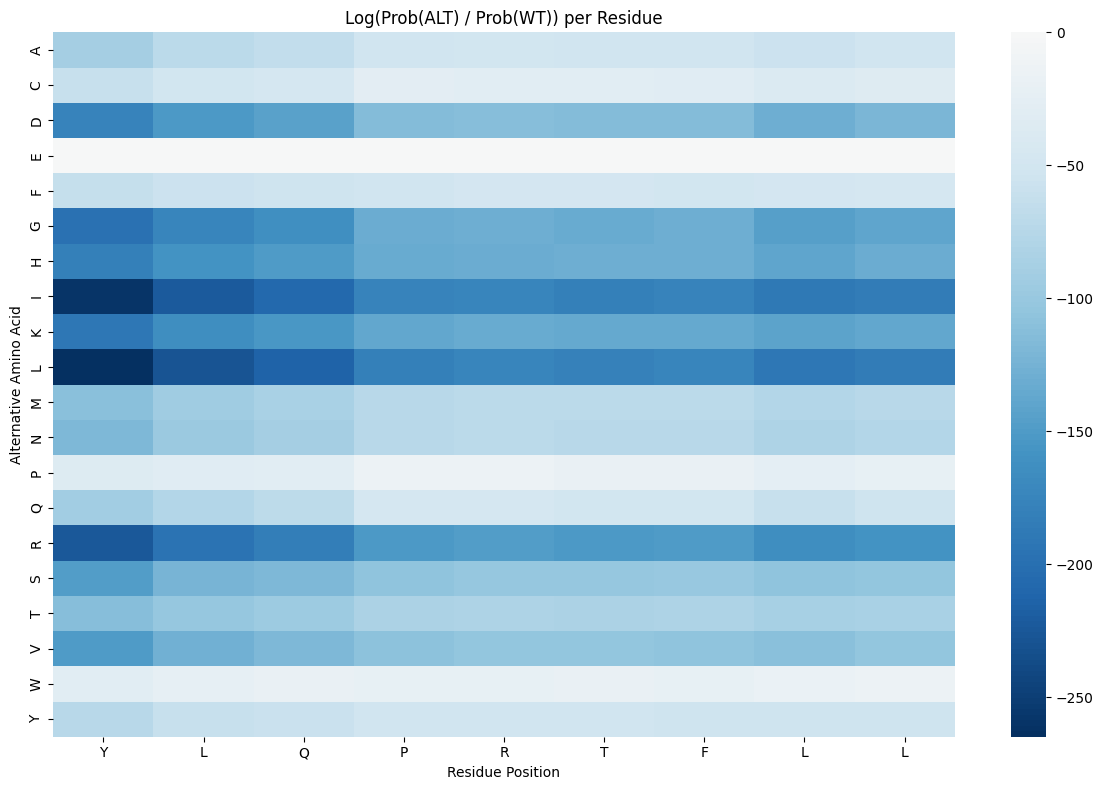

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the raw logits matrix CSV
logits_path = '/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/ESMCBA/logits.csv'
df = pd.read_csv(logits_path, index_col=0)
df.index = list('YLQPRTFLL')  # Set residue names as index
print("Raw logits matrix shape:", df.shape)
print("Raw logits matrix:")
print(df.head())

# 2. Remove special tokens (keep only amino acid columns)
amino_acids = ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 
               'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y']
               
df = df.loc[:, [col for col in df.columns if col in amino_acids]]
print("Filtered matrix shape:", df.shape)

# 3. Convert DataFrame to NumPy array for cleaner operations
logits = df.to_numpy()  # Convert to NumPy array early
print("Logits array shape:", logits.shape)

# 4. Convert logits to probabilities using softmax
exp_logits = np.exp(logits)
probs = exp_logits / exp_logits.sum(axis=1)[:, np.newaxis]
print("Probabilities shape:", probs.shape)

# 5. Define WT sequence and get WT probabilities
wt_sequence = list('YLQPRTFLL')
wt_indices = [amino_acids.index(aa) for aa in wt_sequence]  # Convert WT amino acids to column indices
wt_probs = probs[np.arange(len(wt_sequence)), wt_indices]  # Extract WT probs using advanced indexing
print("WT probabilities shape:", wt_probs.shape)

# 6. Calculate log odds ratio: log(Prob(ALT) / Prob(WT))
log_odds = np.log(probs)
print("Log odds shape:", log_odds.shape)

# 7. Create heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(log_odds.T, 
            cmap='RdBu_r', 
            center=0, 
            annot=False, 
            yticklabels=amino_acids,
            xticklabels=wt_sequence)
plt.title('Log(Prob(ALT) / Prob(WT)) per Residue')
plt.ylabel('Alternative Amino Acid')
plt.xlabel('Residue Position')
plt.tight_layout()
plt.show()

In [ ]:
df

,L,A,G,V,S,E,R,T,I,D,P,K,Q,N,F,Y,M,H,W,C
Y,48.412518,77.155106,-37.374836,138.870360,76.022250,-59.548172,-43.002457,-121.66588,-52.351112,-126.059710,27.672058,19.138996,103.616100,46.930443,-85.968100,-8.278480,27.055159,-11.021359,108.447910,65.831375
L,48.129993,67.766660,-34.155210,118.684555,61.766594,-56.124130,-39.532536,-104.81594,-46.815804,-109.585180,24.662731,19.668060,86.647520,40.303340,-76.018160,-4.990909,17.180344,-7.877485,95.414375,57.742416
Q,44.741207,63.890453,-33.794327,110.719574,55.333080,-51.880432,-39.223750,-97.23726,-43.131973,-103.815384,25.255327,21.072310,81.714676,41.377270,-71.861720,-7.305161,14.531095,-8.891874,90.825400,51.577522
P,38.789590,62.112900,-24.165365,90.738500,38.555622,-40.868640,-43.085840,-87.18355,-47.106220,-89.422745,17.761919,17.882698,75.716576,43.792614,-60.650425,-15.893112,7.086301,-16.913963,68.964850,37.943375
R,38.320923,59.511030,-23.487082,88.671310,39.043570,-41.088696,-42.450886,-85.96540,-45.694680,-85.215034,16.714516,17.497930,72.443510,41.952282,-59.466698,-13.126841,6.699055,-15.043299,67.354670,36.422450
T,38.052837,60.917213,-24.278112,91.263750,42.156265,-41.468372,-39.093166,-89.28793,-44.093613,-87.492645,19.224960,18.063179,72.371210,40.753445,-61.407413,-11.065847,8.118165,-13.373490,71.096600,38.104694
F,38.740370,59.397465,-23.505245,90.879715,40.978073,-39.455288,-39.512253,-86.71881,-44.569286,-84.439926,19.449780,17.800018,71.337310,39.690290,-59.352860,-10.373219,8.748087,-15.572234,70.142944,37.029434
L,42.893745,61.814842,-28.707512,99.697140,50.885937,-46.970703,-39.646000,-90.03729,-42.370705,-92.337550,22.484074,17.513065,74.800760,39.393578,-64.630150,-7.869593,10.941708,-10.837225,82.599960,44.557860
L,41.505520,61.179478,-26.219471,94.634315,48.126220,-44.632740,-37.228436,-89.82255,-42.462110,-90.534070,21.901012,17.257206,72.408936,40.204384,-63.610000,-9.477133,9.057033,-9.851454,78.214400,40.649654


In [ ]:
pd.DataFrame(log_odds, index=wt_sequence, columns=amino_acids)

,A,C,D,E,F,G,H,I,K,L,M,N,P,Q,R,S,T,V,W,Y
Y,-90.457842,-61.715254,-176.245196,-6.172840e-14,-62.848110,-198.418532,-181.872817,-260.536240,-191.221472,-264.930070,-111.198302,-119.731364,-35.254260,-91.939917,-224.838460,-147.148840,-111.815201,-149.891719,-30.422450,-73.038985
L,-70.554562,-50.917895,-152.839765,-7.833512e-11,-56.917961,-174.808685,-158.217091,-223.500495,-165.500359,-228.269735,-94.021824,-99.016495,-32.037035,-78.381215,-194.702715,-123.675464,-101.504211,-126.562040,-23.270180,-60.942139
Q,-65.978367,-46.829121,-144.513901,-2.291490e-09,-55.386494,-162.600006,-149.943324,-207.956834,-153.851547,-214.534958,-85.464247,-89.647264,-29.004898,-69.342304,-182.581294,-118.024735,-96.188479,-119.611448,-19.894174,-59.142052
P,-51.948910,-28.625600,-114.903865,-2.996188e-07,-52.182878,-131.607140,-133.824340,-177.922050,-137.844720,-180.161245,-72.976581,-72.855802,-15.021924,-46.945886,-151.388925,-106.631612,-83.652199,-107.652463,-21.773650,-52.795125
R,-50.350387,-29.160280,-112.158392,-9.016258e-08,-49.627740,-129.760006,-131.122196,-174.636710,-134.365990,-173.886344,-71.956794,-71.173380,-16.227800,-46.719028,-148.138008,-101.798151,-81.972255,-103.714609,-21.316640,-52.248860
T,-53.210913,-30.346537,-115.541862,-7.982365e-09,-49.107485,-132.732122,-130.356916,-180.551680,-135.357363,-178.756395,-72.038790,-73.200571,-18.892540,-50.510305,-152.671163,-102.329597,-83.145585,-104.637240,-20.167150,-53.159056
F,-52.139345,-31.482250,-114.384960,-4.243784e-09,-49.901642,-130.335003,-130.391968,-177.598525,-135.449001,-175.319641,-71.429935,-73.079697,-19.542405,-51.189425,-150.232575,-101.252934,-82.131628,-106.451949,-20.736771,-53.850281
L,-56.803395,-37.882298,-128.404652,-3.758089e-08,-48.811203,-146.667843,-139.343140,-189.734430,-142.067845,-192.034690,-77.213066,-82.184075,-24.896380,-60.303562,-164.327290,-107.566733,-88.755432,-110.534365,-17.097180,-55.139280
L,-53.128795,-33.454837,-120.853786,-7.416982e-08,-46.508095,-139.267055,-131.862751,-184.456865,-137.096425,-185.168385,-72.733303,-77.377109,-22.225379,-54.429931,-158.244315,-104.111448,-85.577282,-104.485769,-16.419915,-53.984661


In [ ]:
break 

In [ ]:
dqwqw

In [ ]:
https://www.rcsb.org/structure/7RTD

Text(0.5, 1.0, 'Histogram of Token-level NLLs')

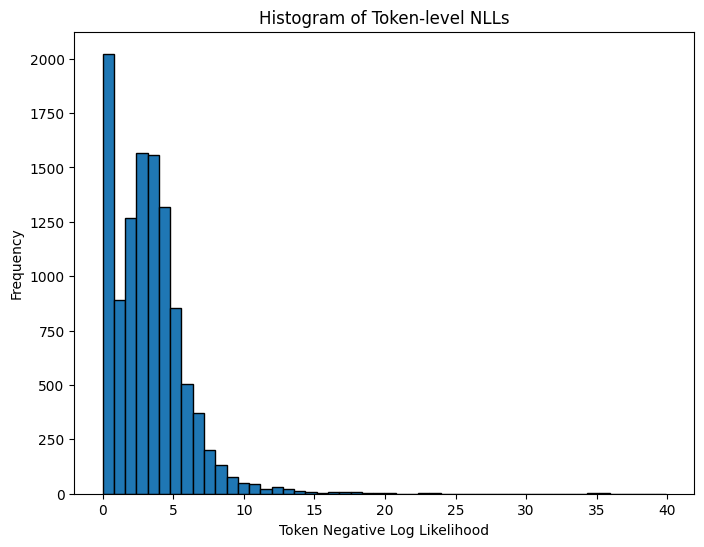

In [34]:
plt.figure(figsize=(8, 6))
plt.hist(df['token_nll'], bins=50, edgecolor='black')
plt.xlabel("Token Negative Log Likelihood")
plt.ylabel("Frequency")
plt.title("Histogram of Token-level NLLs")

In [35]:
directory = '/global/scratch/users/sergiomar10/models/ESMC_Pretrain/'
summary_df['model_path'] = directory + 'HLAHLA' + summary_df['HLA'] + '/' + summary_df['File'].str.replace('_per_token_metrics.csv','.pt')
# /global/scratch/users/sergiomar10/models/ESMC_Pretrain/HLAHLAB2703/ESMMASK_epitope_FT_15_0.001_1e-06_AUG_6_HLAB2703_2.pt

In [36]:
summary_df = summary_df[summary_df['HLA'].apply(len) > 4]

In [37]:
summary_df = summary_df.drop_duplicates('HLA').reset_index(drop=True)

In [41]:
summary_df

,File,HLA,Avg_Token_NLL,model_path
0,ESMMASK_epitope_FT_15_0.001_1e-06_AUG_6_HLAB27...,B2703,0.000004,/global/scratch/users/sergiomar10/models/ESMC_...
1,ESMMASK_epitope_FT_25_0.001_5e-05_AUG_1_HLAA02...,A0201,2.458064,/global/scratch/users/sergiomar10/models/ESMC_...
2,ESMMASK_epitope_FT_20_0.001_1e-06_AUG_6_HLAA11...,A1101,3.082512,/global/scratch/users/sergiomar10/models/ESMC_...
3,ESMMASK_epitope_FT_20_0.001_1e-06_AUG_6_HLAA11...,HLAA1101,3.082512,/global/scratch/users/sergiomar10/models/ESMC_...
4,ESMMASK_epitope_FT_25_0.001_5e-05_AUG_3_HLAA31...,A3101,3.800563,/global/scratch/users/sergiomar10/models/ESMC_...
...,...,...,...,...
90,ESMMASK_epitope_FT_25_0.001_5e-05_AUG_6_HLAB35...,B3503,inf,/global/scratch/users/sergiomar10/models/ESMC_...
91,ESMMASK_epitope_FT_25_0.001_5e-05_AUG_6_HLAB42...,B4201,inf,/global/scratch/users/sergiomar10/models/ESMC_...
92,ESMMASK_epitope_FT_25_0.001_5e-05_AUG_3_HLAA11...,A1102,inf,/global/scratch/users/sergiomar10/models/ESMC_...
93,ESMMASK_epitope_FT_20_0.001_5e-05_AUG_3_HLAA02...,A0204,inf,/global/scratch/users/sergiomar10/models/ESMC_...


In [ ]:
summary_df.to_csv('file_paths.csv')

In [ ]:
# sorted_acuraccies = []
# for file_name in glob.glob('/global/scratch/users/sergiomar10/models/ESMC_Pretrain/*/*.pt'):
#     try:
#         file_name = file_name.split('/')[-1].replace('.pt', '.csv')
#         file_name = f'/global/scratch/users/sergiomar10/data/ESMC_Pretrain/{file_name}'
#         eval_df = pd.read_csv(file_name)
#         eval_df = eval_df[eval_df['original_aa'] != '<eos>']
#         eval_df['correct'] = eval_df['original_aa'] == eval_df['predicted_aa']
#         size_of_eval_set = len(eval_df)
#         creation_time = os.path.getctime(file_name)
#         creation_date = datetime.datetime.fromtimestamp(creation_time)
#         acuraccy = len(eval_df[eval_df['correct'] == 1]) / len(eval_df)
#         sorted_acuraccies.append([file_name, creation_date, size_of_eval_set, acuraccy])
#     except:
#         print(file_name)

# eval_acc = pd.DataFrame(sorted_acuraccies, columns=['file', 'date', 'eval_set_size', 'accuracy'])
# eval_acc = eval_acc[eval_acc['accuracy'] < 0.8]

### Create SLURM files

In [ ]:
################################################
# 6. Define a simple FASTA parser
################################################
def parse_fasta(file_path):
    sequences = []
    with open(file_path, 'r') as f:
        header = None
        seq = ""
        for line in f:
            line = line.strip()
            if line.startswith(">"):
                if seq:
                    sequences.append((header, seq))
                    seq = ""
                header = line[1:]
            else:
                seq += line
        # Append the last sequence if present
        if seq:
            sequences.append((header, seq))
    return sequences


############################################
# 7. Load and filter the data
############################################
train_fasta = "/global/scratch/users/sergiomar10/jupyter_notebooks/hla_protein_sequences.fasta"
all_data = parse_fasta(train_fasta)

filtered_data = []
for header, sequence in all_data:
    if sequence[0] != 'M':
        continue
    if len(sequence) < 50:
        continue
    if 'X' in sequence:
        continue

    header = header.split('|')[1][:7].replace('*','').replace(':','')

    filtered_data.append(('HLA' + header))
    

In [ ]:
import os

#########################################################
# FASTA Parser
#########################################################
def parse_fasta(file_path):
    sequences = []
    with open(file_path, 'r') as f:
        header = None
        seq = ""
        for line in f:
            line = line.strip()
            if line.startswith(">"):
                if seq:
                    sequences.append((header, seq))
                    seq = ""
                header = line[1:]
            else:
                seq += line
        if seq:
            sequences.append((header, seq))
    return sequences

#########################################################
# Load HLA Sequences
#########################################################
fasta_path = "/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/jupyter_notebooks/hla_sequences.fasta"
hla_data = parse_fasta(fasta_path)

hla_sequences = [
    header for header, seq in hla_data
]


In [ ]:
hla_sequences = [x.replace('*','').replace(':','') for x in hla_sequences]

In [ ]:
HLAs = hla_sequences

In [ ]:
import itertools
import os
import glob

script_path = '/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/ESMCBA/models/ESM_Unsupervised/ESM-C_ALLHLAs.py'
sh_file_dir = '/global/scratch/users/sergiomar10/slurm_jobs/ESMC_pretrain3'
os.makedirs(sh_file_dir, exist_ok=True)

trials = [1, 2]
encoding = ['epitope', 'HLA']
blocks_unfrozen = [15, 20, 25]
last_block_lr = [1e-3, 1e-4, 1e-5]
regression_block_lr = [1e-6, 5e-5, 1e-5]
num_augmentations = [1, 3, 4]
                    
for trial_n, encode, num_block, lr_base, lr_reg, HLA, augs  in itertools.product(trials, encoding, blocks_unfrozen, last_block_lr, regression_block_lr, HLAs, num_augmentations):
    
    file_name = f'ESMMASK_{encode}_FT_{num_block}_{lr_base}_{lr_reg}_AUG_{augs}_{HLA}_{trial_n}'

    sh_filename = f'{file_name}.sh'
    sh_filepath = os.path.join(sh_file_dir, sh_filename)
    
    # Construct the command to run the script with the current parameters
    cmd = f'python3 {script_path} --name_of_model {file_name} --encoding {encode} --blocks_unfrozen {num_block} --base_block_lr {lr_base} --regression_block_lr {lr_reg} --HLA HLA{HLA} --num_augmentations {augs}'

    with open(sh_filepath, 'w') as sh_file:
        sh_file.write('#!/bin/bash\n')
        sh_file.write('#SBATCH --account=co_nilah\n')
        sh_file.write('#SBATCH --partition=savio2_1080ti\n')
        sh_file.write('#SBATCH --qos=savio_lowprio\n')
        sh_file.write('#SBATCH --cpus-per-task=4\n')
        sh_file.write('#SBATCH --gres=gpu:1\n')
        sh_file.write('#SBATCH --requeue\n')
        sh_file.write('#SBATCH --time=03:00:00\n')
        sh_file.write(f'#SBATCH --job-name={file_name}\n')
        sh_file.write(f'#SBATCH --output=/global/scratch/users/sergiomar10/logs/ESMC_Pretrain/{file_name}_%j.out\n')
        sh_file.write(f'#SBATCH --error=/global/scratch/users/sergiomar10/logs/ESMC_Pretrain/{file_name}_%j.err\n')
        sh_file.write('source /clusterfs/nilah/sergio/miniconda3/etc/profile.d/conda.sh\n')
        sh_file.write('\n')
        sh_file.write('conda activate ESM_cambrian\n')
        sh_file.write('\n')

        sh_file.write(cmd + '\n')
        
    # Make the shell script executable
    os.chmod(sh_filepath, 0o755)
    
    print(f'Created shell script: {file_name}')
    # break


Created shell script: ESMMASK_epitope_FT_15_0.001_1e-06_AUG_1_A0101_1
Created shell script: ESMMASK_epitope_FT_15_0.001_1e-06_AUG_3_A0101_1
Created shell script: ESMMASK_epitope_FT_15_0.001_1e-06_AUG_4_A0101_1
Created shell script: ESMMASK_epitope_FT_15_0.001_1e-06_AUG_1_A0201_1
Created shell script: ESMMASK_epitope_FT_15_0.001_1e-06_AUG_3_A0201_1
Created shell script: ESMMASK_epitope_FT_15_0.001_1e-06_AUG_4_A0201_1
Created shell script: ESMMASK_epitope_FT_15_0.001_1e-06_AUG_1_A0202_1
Created shell script: ESMMASK_epitope_FT_15_0.001_1e-06_AUG_3_A0202_1
Created shell script: ESMMASK_epitope_FT_15_0.001_1e-06_AUG_4_A0202_1
Created shell script: ESMMASK_epitope_FT_15_0.001_1e-06_AUG_1_A0203_1
Created shell script: ESMMASK_epitope_FT_15_0.001_1e-06_AUG_3_A0203_1
Created shell script: ESMMASK_epitope_FT_15_0.001_1e-06_AUG_4_A0203_1
Created shell script: ESMMASK_epitope_FT_15_0.001_1e-06_AUG_1_A0204_1
Created shell script: ESMMASK_epitope_FT_15_0.001_1e-06_AUG_3_A0204_1
Created shell script